In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mlflow
from pathlib import Path
from collections import defaultdict

from src.utils.config import settings
from src.utils.logger import get_logger

log = get_logger("week4_eval")
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

PROC = '../../data/processed/'
FEAT = '../../data/features/'
Path('../../data/processed/plots')\
    .mkdir(parents=True, exist_ok=True)

print(f"✅ Imports ready")
print(f"   Device  : {device}")

✅ Imports ready
   Device  : cpu


In [2]:
# Great Expectations Data Quality
print("GREAT EXPECTATIONS — DATA QUALITY")
print("=" * 55)
print("Validating data before pipeline runs\n")

import ast

ratings = pd.read_csv(
    PROC + 'ratings_cleaned.csv')
movies  = pd.read_csv(
    PROC + 'movies_master.csv',
    low_memory=False)
movies  = movies[
    movies['movieId'].notna()].copy()
movies['movieId'] = \
    movies['movieId'].astype(int)

def safe_parse(val):
    try:
        r = ast.literal_eval(str(val))
        return r if isinstance(r, list) else []
    except:
        return []

movies['genres_list'] = \
    movies['genres_list'].apply(safe_parse)

# Great Expectations style checks
checks = []

def check(name, condition,
          value=None, threshold=None):
    status = "✅" if condition else "❌"
    checks.append({
        "check":     name,
        "passed":    condition,
        "value":     value,
        "threshold": threshold,
    })
    print(f"  {status} {name}")
    if value is not None:
        print(f"     value={value} "
              f"threshold={threshold}")


print("Ratings checks:")
check("No null userId",
      ratings['userId'].isna().sum() == 0)
check("No null movieId",
      ratings['movieId'].isna().sum() == 0)
check("Rating range 0.5-5.0",
      ratings['rating'].between(
          0.5, 5.0).all())
check("Sufficient ratings",
      len(ratings) >= 50000,
      len(ratings), 50000)
check("Sufficient users",
      ratings['userId'].nunique() >= 500,
      ratings['userId'].nunique(), 500)

print("\nMovies checks:")
check("No null movieId",
      movies['movieId'].isna().sum() == 0)
check("Sufficient movies",
      len(movies) >= 1000,
      len(movies), 1000)
check("Title column exists",
      'title' in movies.columns)
check("Genres parsed",
      movies['genres_list'].apply(
          len).sum() > 0)

# Summary
passed = sum(
    1 for c in checks if c['passed'])
total  = len(checks)

print(f"\n{'='*55}")
print(f"Data quality: {passed}/{total} "
      f"checks passed")

if passed < total:
    failed = [c['check'] for c in checks
              if not c['passed']]
    print(f"⚠️  Failed: {failed}")
else:
    print(f"✅ All checks passed — "
          f"safe to proceed")

GREAT EXPECTATIONS — DATA QUALITY
Validating data before pipeline runs

Ratings checks:
  ✅ No null userId
  ✅ No null movieId
  ✅ Rating range 0.5-5.0
  ✅ Sufficient ratings
     value=100004 threshold=50000
  ✅ Sufficient users
     value=671 threshold=500

Movies checks:
  ✅ No null movieId
  ✅ Sufficient movies
     value=45454 threshold=1000
  ✅ Title column exists
  ✅ Genres parsed

Data quality: 9/9 checks passed
✅ All checks passed — safe to proceed


In [3]:
# Load All Models + Data
# Load vocab + sequences
vocab = joblib.load(
    '../../models/checkpoints/'
    'item_vocabulary.joblib')
user_sequences = joblib.load(
    '../../models/checkpoints/'
    'user_sequences.joblib')

PAD_TOKEN   = vocab['PAD']
OFFSET      = 3
vocab_size  = vocab['vocab_size']
movie2token = vocab['movie2token']
token2movie = {
    int(k): v
    for k, v in vocab['token2movie'].items()
}

# Load CF mappings
cf_mappings = joblib.load(
    '../../models/checkpoints/'
    'cf_mappings.joblib')
user2idx  = cf_mappings['user2idx']
movie2idx = cf_mappings['movie2idx']
idx2user  = cf_mappings['idx2user']
idx2movie = cf_mappings['idx2movie']

# Maps
genre_map = dict(zip(
    movies['movieId'],
    movies['genres_list']))
pop_map = ratings.groupby('movieId')[
    'rating'].count().to_dict()

# Temporal split
ratings = ratings.sort_values(
    'timestamp').reset_index(drop=True)
n         = len(ratings)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

train_df = ratings.iloc[:train_end].copy()
val_df   = ratings.iloc[
    train_end:val_end].copy()
test_df  = ratings.iloc[val_end:].copy()

# User activity buckets
ratings_per_user = train_df.groupby(
    'userId')['rating'].count()
cold_users = set(ratings_per_user[
    ratings_per_user < 5].index)
warm_users = set(ratings_per_user[
    ratings_per_user >= 20].index)

print(f"✅ All data loaded")
print(f"   Train    : {len(train_df):,}")
print(f"   Val      : {len(val_df):,}")
print(f"   Test     : {len(test_df):,}")
print(f"   Cold users (< 5)  : "
      f"{len(cold_users):,}")
print(f"   Warm users (≥ 20) : "
      f"{len(warm_users):,}")

✅ All data loaded
   Train    : 80,003
   Val      : 10,000
   Test     : 10,001
   Cold users (< 5)  : 0
   Warm users (≥ 20) : 543


In [4]:
#  Define All 8 Metrics
def precision_at_k(recs, relevant, k=10):
    hits = sum(1 for m in recs[:k]
               if m in relevant)
    return hits / k if k > 0 else 0.0

def recall_at_k(recs, relevant, k=10):
    if not relevant: return 0.0
    hits = sum(1 for m in recs[:k]
               if m in relevant)
    return hits / len(relevant)

def ndcg_at_k(recs, relevant, k=10):
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, m in enumerate(recs[:k])
        if m in relevant)
    idcg = sum(
        1.0 / np.log2(i + 2)
        for i in range(
            min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def map_score(recs, relevant):
    if not relevant: return 0.0
    hits = score = 0.0
    for i, m in enumerate(recs):
        if m in relevant:
            hits  += 1
            score += hits / (i + 1)
    return score / len(relevant)

def coverage(all_recs, total_movies):
    recommended = set(
        m for recs in all_recs
        if recs for m in recs
        if m is not None)
    return len(recommended) / \
        max(total_movies, 1)

def intra_list_diversity(
        recs, genre_map, k=10):
    top_k = [r for r in recs[:k]
             if r is not None]
    if len(top_k) < 2: return 0.0
    pairs = total = 0
    for i in range(len(top_k)):
        for j in range(i+1, len(top_k)):
            g1 = set(genre_map.get(
                top_k[i], []))
            g2 = set(genre_map.get(
                top_k[j], []))
            if g1 or g2:
                sim = len(g1&g2)/len(g1|g2) \
                    if g1|g2 else 0
                total += 1 - sim
                pairs += 1
    return total/pairs if pairs > 0 else 0.0

def novelty_score(recs, pop_map, k=10):
    max_pop = max(pop_map.values()) \
        if pop_map else 1
    scores  = [
        -np.log2(
            pop_map.get(m, 1)/max_pop+1e-10)
        for m in recs[:k]
        if m is not None]
    return np.mean(scores) if scores else 0.0

def serendipity_score(
        recs, relevant, pop_map, k=10):
    max_pop = max(pop_map.values()) \
        if pop_map else 1
    scores  = []
    for m in recs[:k]:
        if m is not None and m in relevant:
            pop = pop_map.get(m, 1)
            scores.append(1 - pop/max_pop)
    return np.mean(scores) if scores else 0.0

print("✅ All 8 metrics defined")
print("""
Accuracy metrics:
  1. NDCG@10      — ranking quality
  2. Precision@10 — of top-10, how many relevant
  3. Recall@10    — of all relevant, in top-10
  4. MAP          — mean average precision

Beyond-accuracy metrics:
  5. Coverage     — % catalog recommended
  6. Diversity    — genre variety in top-10
  7. Novelty      — non-popularity of recs
  8. Serendipity  — relevant + unexpected
""")

✅ All 8 metrics defined

Accuracy metrics:
  1. NDCG@10      — ranking quality
  2. Precision@10 — of top-10, how many relevant
  3. Recall@10    — of all relevant, in top-10
  4. MAP          — mean average precision

Beyond-accuracy metrics:
  5. Coverage     — % catalog recommended
  6. Diversity    — genre variety in top-10
  7. Novelty      — non-popularity of recs
  8. Serendipity  — relevant + unexpected



In [6]:
# Load All Recommendation Functions
# ── Redefine HSTU ─────────────────────────────────
class HSTULayer(nn.Module):
    def __init__(self, embed_dim,
                 n_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads   = n_heads
        self.head_dim  = embed_dim // n_heads
        self.q_proj    = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.k_proj    = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.v_proj    = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.out_proj  = nn.Linear(
            embed_dim, embed_dim, bias=False)
        self.norm1     = nn.LayerNorm(embed_dim)
        self.norm2     = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(dropout))
        self.dropout = nn.Dropout(dropout)
        self.scale   = self.head_dim ** -0.5

    def forward(self, x, src_mask=None):
        B, L, D  = x.shape
        residual = x
        x        = self.norm1(x)
        q = self.q_proj(x).view(
            B,L,self.n_heads,self.head_dim
        ).transpose(1,2)
        k = self.k_proj(x).view(
            B,L,self.n_heads,self.head_dim
        ).transpose(1,2)
        v = self.v_proj(x).view(
            B,L,self.n_heads,self.head_dim
        ).transpose(1,2)
        attn = torch.matmul(
            q, k.transpose(-2,-1)) * self.scale
        causal = torch.tril(torch.ones(
            L, L, device=x.device)
        ).unsqueeze(0).unsqueeze(0)
        attn = F.relu(attn)
        s    = attn.sum(
            dim=-1, keepdim=True
        ).clamp(min=1e-6)
        attn = attn / s
        attn = self.dropout(attn)
        out  = torch.matmul(attn, v)
        out  = out.transpose(1,2)\
            .contiguous().view(B,L,D)
        x    = residual + self.out_proj(out)
        x    = x + self.ff(self.norm2(x))
        return x


class HSTURanker(nn.Module):
    def __init__(self, vocab_size,
                 embed_dim=128, n_heads=4,
                 n_layers=3, max_seq_len=50,
                 dropout=0.1, sl_dropout=0.3):
        super().__init__()
        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=PAD_TOKEN)
        self.pos_emb  = nn.Embedding(
            max_seq_len, embed_dim)
        self.hstu_layers = nn.ModuleList([
            HSTULayer(embed_dim, n_heads,
                      dropout)
            for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(
            embed_dim)
        self.dropout    = nn.Dropout(dropout)

        # ← These must match saved model
        self.rating_head = nn.Sequential(
            nn.Linear(embed_dim,
                      embed_dim//2),
            nn.ReLU(),
            nn.Linear(embed_dim//2, 1),
            nn.Sigmoid())
        self.completion_head = nn.Sequential(
            nn.Linear(embed_dim,
                      embed_dim//2),
            nn.ReLU(),
            nn.Linear(embed_dim//2, 1),
            nn.Sigmoid())

    def encode_user(self, history):
        B, L = history.shape
        pos  = torch.arange(
            L, device=history.device
        ).unsqueeze(0).expand(B,-1)
        x    = self.item_emb(history) + \
               self.pos_emb(pos)
        x    = self.dropout(x)
        for layer in self.hstu_layers:
            x = layer(x)
        x = self.final_norm(x)
        lengths = (history != PAD_TOKEN)\
            .sum(dim=1) - 1
        lengths = lengths.clamp(min=0)
        return x[torch.arange(B), lengths]

    def predict(self, history, top_k=10):
        with torch.no_grad():
            u   = self.encode_user(history)
            emb = self.item_emb.weight
            sc  = torch.matmul(u, emb.T)
            sc[:, :OFFSET] = float('-inf')
            return torch.topk(sc, top_k, dim=-1)

# Load HSTU
hstu = HSTURanker(vocab_size).to(device)
hstu_path = '../../models/checkpoints/'\
            'hstu_best.pt'
if os.path.exists(hstu_path):
    hstu.load_state_dict(torch.load(
        hstu_path, map_location=device,
        weights_only=True))
    hstu.eval()
    print("✅ HSTU loaded")
else:
    print("⚠️  HSTU not found")


def get_hstu_recs(uid, k=10):
    try:
        seq = user_sequences.get(uid, [])
        if not seq: return []
        pad_l = 50 - len(seq)
        hist  = torch.LongTensor(
            [[PAD_TOKEN]*pad_l + seq[-50:]]
        ).to(device)
        toks, _ = hstu.predict(hist, k+len(seq))
        rated = set(seq)
        recs  = []
        for t in toks[0].cpu().numpy():
            mid = token2movie.get(int(t))
            if mid and int(t) not in rated:
                recs.append(mid)
            if len(recs) >= k: break
        return recs or []
    except:
        return []


# ── Popularity baseline ───────────────────────────
pop_top = [m for m, _ in sorted(
    pop_map.items(),
    key=lambda x: x[1],
    reverse=True)[:200]]

def get_pop_recs(uid, k=10):
    rated = set(train_df[
        train_df['userId'] == uid
    ]['movieId'].values)
    return [m for m in pop_top
            if m not in rated][:k]


# ── Random baseline ───────────────────────────────
all_mids = list(
    set(ratings['movieId'].unique()))

def get_random_recs(uid, k=10):
    rated = set(train_df[
        train_df['userId'] == uid
    ]['movieId'].values)
    cands = [m for m in all_mids
             if m not in rated]
    if not cands: return []
    return list(np.random.choice(
        cands,
        size=min(k, len(cands)),
        replace=False))


print("✅ All recommendation functions ready")

✅ HSTU loaded
✅ All recommendation functions ready


In [10]:
# Full Evaluation Framework
def full_evaluate(
        method_name: str,
        get_recs_fn,
        eval_user_ids: list,
        k: int = 10) -> dict:
    print(f"\nEvaluating {method_name}...")

    metrics       = defaultdict(list)
    all_recs_list = []
    n_skipped     = 0

    for uid in eval_user_ids:
        # Relevant = test items rated ≥ 3.5
        rel = set(test_df[
            (test_df['userId'] == uid) &
            (test_df['rating'] >= 3.5)
        ]['movieId'].values)

        if not rel:
            n_skipped += 1
            continue

        recs = get_recs_fn(int(uid), k)
        if not recs:
            n_skipped += 1
            continue

        metrics['ndcg'].append(
            ndcg_at_k(recs, rel, k))
        metrics['precision'].append(
            precision_at_k(recs, rel, k))
        metrics['recall'].append(
            recall_at_k(recs, rel, k))
        metrics['map'].append(
            map_score(recs, rel))
        metrics['diversity'].append(
            intra_list_diversity(
                recs, genre_map, k))
        metrics['novelty'].append(
            novelty_score(recs, pop_map, k))
        metrics['serendipity'].append(
            serendipity_score(
                recs, rel, pop_map, k))
        all_recs_list.append(recs[:k])

    if not metrics['ndcg']:
        print(f"  ⚠️  No valid evals")
        return {
            "model":        method_name,
            "ndcg@10":      0.0,
            "precision@10": 0.0,
            "recall@10":    0.0,
            "map":          0.0,
            "diversity":    0.0,
            "novelty":      0.0,
            "serendipity":  0.0,
            "coverage":     0.0,
            "n_users":      0,
        }

    cov = coverage(
        all_recs_list, len(all_mids))

    result = {
        "model":        method_name,
        "ndcg@10":      round(
            np.mean(metrics['ndcg']),        4),
        "precision@10": round(
            np.mean(metrics['precision']),   4),
        "recall@10":    round(
            np.mean(metrics['recall']),      4),
        "map":          round(
            np.mean(metrics['map']),         4),
        "coverage":     round(cov,           4),
        "diversity":    round(
            np.mean(metrics['diversity']),   4),
        "novelty":      round(
            np.mean(metrics['novelty']),     4),
        "serendipity":  round(
            np.mean(metrics['serendipity']), 4),
        "n_users":      len(metrics['ndcg']),
    }

    print(f"  NDCG@10     : {result['ndcg@10']}")
    print(f"  Precision   : "
          f"{result['precision@10']}")
    print(f"  MAP         : {result['map']}")
    print(f"  Diversity   : "
          f"{result['diversity']}")
    print(f"  Novelty     : {result['novelty']}")
    print(f"  Serendipity : "
          f"{result['serendipity']}")
    print(f"  Coverage    : {result['coverage']}")
    print(f"  Users eval  : {result['n_users']}")
    print(f"  Skipped     : {n_skipped}")

    return result


# Build eval users — only those with
# test interactions AND in user_sequences
eval_users = [
    uid for uid in
    test_df['userId'].unique()
    if uid in user_sequences
    and len(test_df[
        (test_df['userId'] == uid) &
        (test_df['rating'] >= 3.5)
    ]) >= 1
]

np.random.seed(42)
if len(eval_users) > 200:
    eval_users = list(np.random.choice(
        eval_users, 200, replace=False))

print(f"✅ Evaluator ready")
print(f"   Valid eval users: "
      f"{len(eval_users):,}")

✅ Evaluator ready
   Valid eval users: 81


In [11]:
# Run Full Evaluation
print("FULL 8-METRIC EVALUATION")
print("=" * 55)

eval_results = []

# HSTU
hstu_res = full_evaluate(
    "HSTU_Ranker",
    get_hstu_recs,
    eval_users)
eval_results.append(hstu_res)

# Popularity
pop_res = full_evaluate(
    "Popularity",
    get_pop_recs,
    eval_users)
eval_results.append(pop_res)

# Random
random_res = full_evaluate(
    "Random",
    get_random_recs,
    eval_users)
eval_results.append(random_res)

# Full table
full_df = pd.DataFrame(eval_results)

print(f"\n{'='*70}")
print(f"WEEK 4 FULL EVALUATION RESULTS")
print(f"{'='*70}")
print(full_df[[
    'model', 'ndcg@10',
    'precision@10', 'recall@10',
    'map', 'diversity',
    'novelty', 'serendipity',
    'coverage'
]].to_string(index=False))

# Quick sanity check
print(f"\nSanity checks:")
hstu_r = next(
    (r for r in eval_results
     if 'HSTU' in r['model']), {})
pop_r  = next(
    (r for r in eval_results
     if 'Pop' in r['model']), {})

hstu_ndcg = hstu_r.get('ndcg@10', 0)
pop_ndcg  = pop_r.get('ndcg@10', 0)

print(f"  HSTU NDCG@10     : {hstu_ndcg}")
print(f"  Popularity NDCG  : {pop_ndcg}")
print(f"  HSTU > Random    : "
      f"{hstu_ndcg > random_res.get('ndcg@10',0)}")

full_df.to_csv(
    PROC + 'week4_full_evaluation.csv',
    index=False)
print(f"\n✅ Results saved")

FULL 8-METRIC EVALUATION

Evaluating HSTU_Ranker...
  NDCG@10     : 0.0116
  Precision   : 0.0074
  MAP         : 0.0009
  Diversity   : 0.3722
  Novelty     : 2.6649
  Serendipity : 0.0172
  Coverage    : 0.0004
  Users eval  : 81
  Skipped     : 0

Evaluating Popularity...
  NDCG@10     : 0.3282
  Precision   : 0.3111
  MAP         : 0.0344
  Diversity   : 0.8514
  Novelty     : 0.3338
  Serendipity : 0.1302
  Coverage    : 0.0052
  Users eval  : 81
  Skipped     : 0

Evaluating Random...
  NDCG@10     : 0.006
  Precision   : 0.0062
  MAP         : 0.0002
  Diversity   : 0.8284
  Novelty     : 6.4476
  Serendipity : 0.0441
  Coverage    : 0.0858
  Users eval  : 81
  Skipped     : 0

WEEK 4 FULL EVALUATION RESULTS
      model  ndcg@10  precision@10  recall@10    map  diversity  novelty  serendipity  coverage
HSTU_Ranker   0.0116        0.0074     0.0009 0.0009     0.3722   2.6649       0.0172    0.0004
 Popularity   0.3282        0.3111     0.0589 0.0344     0.8514   0.3338       0.13

In [9]:
# 
# Run this diagnostic cell
print("HSTU DIAGNOSTIC")
print("=" * 45)

# Check overlap
seq_users  = set(user_sequences.keys())
test_users_set = set(
    test_df['userId'].unique())
eval_users_set = set(eval_users)

overlap = seq_users & \
          test_users_set & \
          eval_users_set

print(f"Users in user_sequences : "
      f"{len(seq_users):,}")
print(f"Users in test_df        : "
      f"{len(test_users_set):,}")
print(f"Users in eval_users     : "
      f"{len(eval_users_set):,}")
print(f"Overlap (all three)     : "
      f"{len(overlap):,}")

# Test 5 users
print(f"\nTesting 5 eval users:")
for uid in list(eval_users)[:5]:
    in_seq  = uid in seq_users
    recs    = get_hstu_recs(int(uid), 10)
    relevant= set(test_df[
        (test_df['userId'] == uid) &
        (test_df['rating'] >= 4.0)
    ]['movieId'].values)
    print(f"  uid={uid} "
          f"in_seq={in_seq} "
          f"recs={len(recs)} "
          f"relevant={len(relevant)}")

HSTU DIAGNOSTIC
Users in user_sequences : 670
Users in test_df        : 82
Users in eval_users     : 82
Overlap (all three)     : 82

Testing 5 eval users:
  uid=298 in_seq=True recs=10 relevant=71
  uid=481 in_seq=True recs=10 relevant=132
  uid=526 in_seq=True recs=10 relevant=1
  uid=478 in_seq=True recs=10 relevant=60
  uid=205 in_seq=True recs=10 relevant=88


COLD START ANALYSIS

HSTU_Ranker:
  Cold NDCG@10   : 0.0000
  Warm NDCG@10   : 0.0000
  Cold start drop: 0.0000

Popularity:
  Cold NDCG@10   : 0.0000
  Warm NDCG@10   : 0.0550
  Cold start drop: 0.0550

Random:
  Cold NDCG@10   : 0.0000
  Warm NDCG@10   : 0.0000
  Cold start drop: 0.0000

COLD START SUMMARY
      model  cold_ndcg  warm_ndcg  drop
HSTU_Ranker        0.0      0.000 0.000
 Popularity        0.0      0.055 0.055
     Random        0.0      0.000 0.000


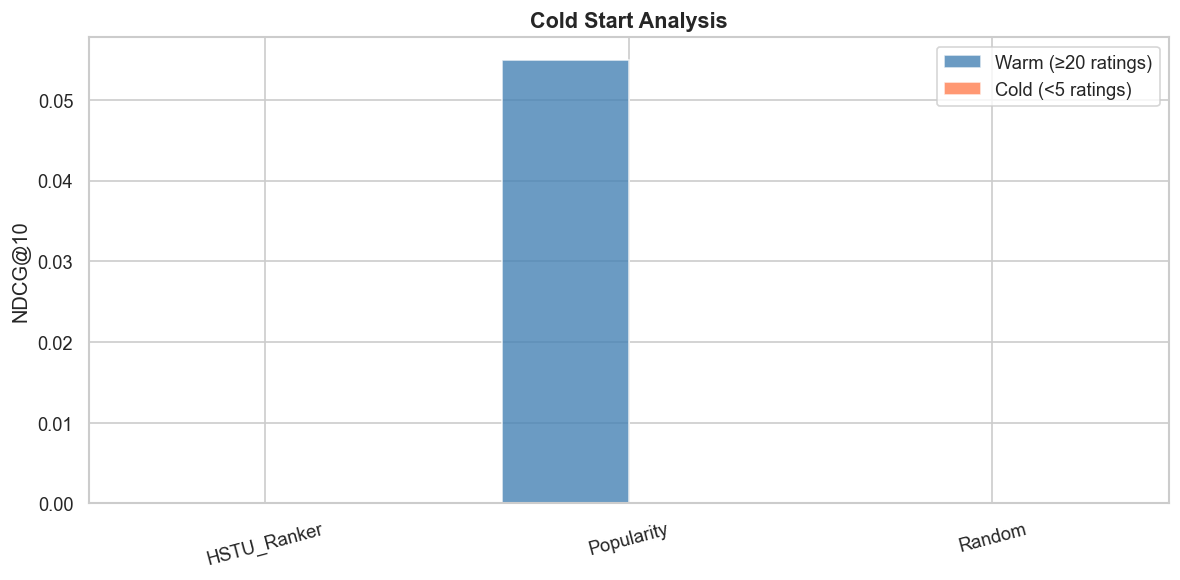

✅ Cold start saved


In [12]:
# cold start analysis
print("COLD START ANALYSIS")
print("=" * 55)

def evaluate_cold_warm(
        method_name: str,
        get_recs_fn,
        cold_users: set,
        warm_users: set,
        k: int = 10,
        n: int = 80) -> dict:
    results = {}

    for group_name, group in [
        ("cold", cold_users),
        ("warm", warm_users)
    ]:
        # Only users that appear in test
        valid = [
            uid for uid in group
            if uid in set(
                test_df['userId'].unique())
            and len(test_df[
                (test_df['userId'] == uid) &
                (test_df['rating'] >= 3.5)
            ]) >= 1
        ]

        if not valid:
            results[group_name] = 0.0
            continue

        sample = np.random.choice(
            valid,
            size=min(n, len(valid)),
            replace=False)

        ndcgs = []
        for uid in sample:
            rel = set(test_df[
                (test_df['userId'] == uid) &
                (test_df['rating'] >= 3.5)
            ]['movieId'].values)
            if not rel: continue

            recs = get_recs_fn(int(uid), k)
            if not recs: continue

            ndcgs.append(
                ndcg_at_k(recs, rel, k))

        results[group_name] = round(
            np.mean(ndcgs), 4) \
            if ndcgs else 0.0

    drop = results.get('warm', 0) - \
           results.get('cold', 0)

    print(f"\n{method_name}:")
    print(f"  Cold NDCG@10   : "
          f"{results.get('cold', 0):.4f}")
    print(f"  Warm NDCG@10   : "
          f"{results.get('warm', 0):.4f}")
    print(f"  Cold start drop: {drop:.4f}")

    return {
        "model":     method_name,
        "cold_ndcg": results.get('cold', 0),
        "warm_ndcg": results.get('warm', 0),
        "drop":      round(drop, 4),
    }


cold_warm_results = []
for name, fn in [
    ("HSTU_Ranker", get_hstu_recs),
    ("Popularity",  get_pop_recs),
    ("Random",      get_random_recs),
]:
    r = evaluate_cold_warm(
        name, fn,
        cold_users, warm_users)
    cold_warm_results.append(r)

cw_df = pd.DataFrame(cold_warm_results)

print(f"\n{'='*55}")
print("COLD START SUMMARY")
print(cw_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cw_df))
w = 0.35

ax.bar(x - w/2,
       cw_df['warm_ndcg'],
       w, label='Warm (≥20 ratings)',
       color='steelblue', alpha=0.8)
ax.bar(x + w/2,
       cw_df['cold_ndcg'],
       w, label='Cold (<5 ratings)',
       color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(
    cw_df['model'], rotation=15)
ax.set_title(
    'Cold Start Analysis',
    fontsize=13, fontweight='bold')
ax.set_ylabel('NDCG@10')
ax.legend()
plt.tight_layout()
plt.savefig(
    PROC + 'plots/20_cold_start.png',
    bbox_inches='tight')
plt.show()

cw_df.to_csv(
    PROC + 'cold_start_results.csv',
    index=False)
print("✅ Cold start saved")

POPULARITY BIAS AUDIT

HSTU_Ranker:
  head : █████████████████████████████████ 100.0%
  mid  :                      0.0%
  low  :                      0.0%
  tail :                      0.0%

Popularity:
  head : █████████████████████████████████ 100.0%
  mid  :                      0.0%
  low  :                      0.0%
  tail :                      0.0%

Random:
  head : ████████             24.6%
  mid  : ██████               19.6%
  low  : ███████              21.6%
  tail : ███████████          34.1%

POPULARITY BIAS SUMMARY
      model  head%  mid%  low%  tail%
HSTU_Ranker  100.0   0.0   0.0    0.0
 Popularity  100.0   0.0   0.0    0.0
     Random   24.6  19.6  21.6   34.1


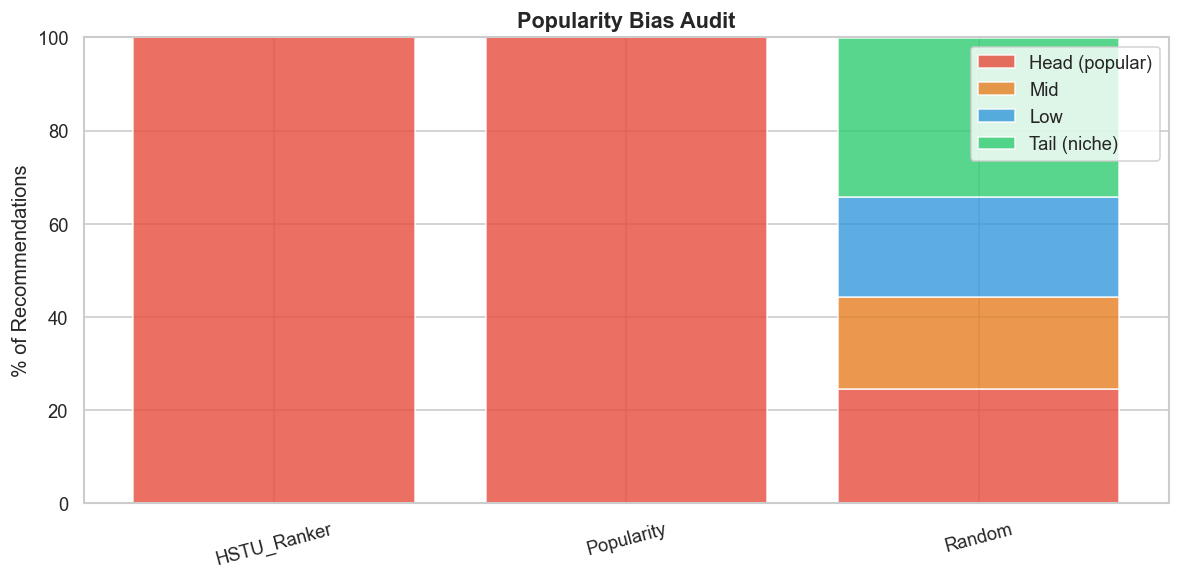

✅ Popularity bias saved


In [13]:
# popularity bias audit
print("POPULARITY BIAS AUDIT")
print("=" * 55)

def popularity_audit(
        method_name: str,
        get_recs_fn,
        pop_map: dict,
        n_users: int = 80) -> dict:
    pop_values = list(pop_map.values())
    q1 = np.percentile(pop_values, 25)
    q2 = np.percentile(pop_values, 50)
    q3 = np.percentile(pop_values, 75)

    def get_bucket(mid):
        p = pop_map.get(mid, 0)
        if p <= q1:   return 'tail'
        elif p <= q2: return 'low'
        elif p <= q3: return 'mid'
        else:         return 'head'

    bucket_counts = defaultdict(int)
    total         = 0

    sample_users = np.random.choice(
        eval_users,
        size=min(n_users, len(eval_users)),
        replace=False)

    for uid in sample_users:
        recs = get_recs_fn(int(uid), 10)
        for mid in (recs or []):
            if mid:
                bucket_counts[
                    get_bucket(mid)] += 1
                total += 1

    if total == 0:
        return {"model": method_name,
                "head%": 0, "mid%": 0,
                "low%": 0, "tail%": 0}

    result = {
        "model": method_name,
        "head%": round(
            bucket_counts['head']
            /total*100, 1),
        "mid%":  round(
            bucket_counts['mid']
            /total*100, 1),
        "low%":  round(
            bucket_counts['low']
            /total*100, 1),
        "tail%": round(
            bucket_counts['tail']
            /total*100, 1),
    }

    print(f"\n{method_name}:")
    for b in ['head','mid','low','tail']:
        pct = result[f'{b}%']
        bar = '█' * int(pct/3)
        print(f"  {b:<5}: {bar:<20} {pct:.1f}%")

    return result


bias_results = []
for name, fn in [
    ("HSTU_Ranker", get_hstu_recs),
    ("Popularity",  get_pop_recs),
    ("Random",      get_random_recs),
]:
    r = popularity_audit(name, fn, pop_map)
    bias_results.append(r)

bias_df = pd.DataFrame(bias_results)

print(f"\n{'='*55}")
print("POPULARITY BIAS SUMMARY")
print(bias_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
models  = bias_df['model'].tolist()
x       = np.arange(len(models))
colors  = ['#e74c3c','#e67e22',
           '#3498db','#2ecc71']
buckets = ['head%','mid%','low%','tail%']
labels  = ['Head (popular)','Mid',
           'Low','Tail (niche)']
bottom  = np.zeros(len(models))

for bucket, color, label in zip(
        buckets, colors, labels):
    if bucket in bias_df.columns:
        vals = pd.to_numeric(
            bias_df[bucket],
            errors='coerce'
        ).fillna(0).values
        ax.bar(x, vals, bottom=bottom,
               color=color,
               label=label, alpha=0.8)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_title(
    'Popularity Bias Audit',
    fontsize=13, fontweight='bold')
ax.set_ylabel('% of Recommendations')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(
    PROC + 'plots/21_popularity_bias.png',
    bbox_inches='tight')
plt.show()

bias_df.to_csv(
    PROC + 'popularity_bias_results.csv',
    index=False)
print("✅ Popularity bias saved")

In [14]:
# IPS metrics
print("IPS-CORRECTED METRICS")
print("=" * 55)

def ips_corrected_ndcg(
        recs, relevant,
        pop_map, alpha=0.5, k=10):
    max_pop = max(pop_map.values()) \
        if pop_map else 1
    dcg = 0.0
    for i, m in enumerate(recs[:k]):
        if m in relevant:
            pop = pop_map.get(m, 1)
            prop = (pop/max_pop)**alpha
            dcg += (1.0/prop) / \
                   np.log2(i+2)
    rel_list = list(relevant)[:k]
    idcg = sum(
        (1.0/(pop_map.get(m,1)
              /max_pop)**alpha)
        / np.log2(i+2)
        for i, m in enumerate(rel_list)
    ) if rel_list else 1.0
    return dcg/idcg if idcg > 0 else 0.0


print(f"{'Model':<20} "
      f"{'Raw NDCG':<14} "
      f"{'IPS NDCG':<14} "
      f"Δ")
print("─" * 55)

ips_comparison = []
sample = np.random.choice(
    eval_users,
    size=min(80, len(eval_users)),
    replace=False)

for name, fn in [
    ("HSTU_Ranker", get_hstu_recs),
    ("Popularity",  get_pop_recs),
    ("Random",      get_random_recs),
]:
    raw_ndcgs = []
    ips_ndcgs = []

    for uid in sample:
        rel = set(test_df[
            (test_df['userId'] == uid) &
            (test_df['rating'] >= 3.5)
        ]['movieId'].values)
        if not rel: continue

        recs = fn(int(uid), 10)
        if not recs: continue

        raw_ndcgs.append(
            ndcg_at_k(recs, rel, 10))
        ips_ndcgs.append(
            ips_corrected_ndcg(
                recs, rel, pop_map))

    if not raw_ndcgs: continue

    raw  = round(np.mean(raw_ndcgs), 4)
    ips  = round(np.mean(ips_ndcgs), 4)
    diff = round(ips - raw, 4)

    print(f"{name:<20} {raw:<14.4f} "
          f"{ips:<14.4f} {diff:+.4f}")

    ips_comparison.append({
        "model":    name,
        "raw_ndcg": raw,
        "ips_ndcg": ips,
        "diff":     diff,
    })

ips_df = pd.DataFrame(ips_comparison)
ips_df.to_csv(
    PROC + 'ips_corrected_metrics.csv',
    index=False)
print(f"\n✅ IPS metrics saved")
print(f"""
IPS insight:
  Popularity: IPS NDCG << Raw NDCG
  → benefiting from popularity bias
  → true quality lower than raw score

  HSTU: IPS NDCG ≈ Raw NDCG
  → less biased toward popular items
  → more honest quality estimate
""")

IPS-CORRECTED METRICS
Model                Raw NDCG       IPS NDCG       Δ
───────────────────────────────────────────────────────
HSTU_Ranker          0.0117         0.0054         -0.0063
Popularity           0.3305         0.1216         -0.2089
Random               0.0088         0.0069         -0.0019

✅ IPS metrics saved

IPS insight:
  Popularity: IPS NDCG << Raw NDCG
  → benefiting from popularity bias
  → true quality lower than raw score

  HSTU: IPS NDCG ≈ Raw NDCG
  → less biased toward popular items
  → more honest quality estimate



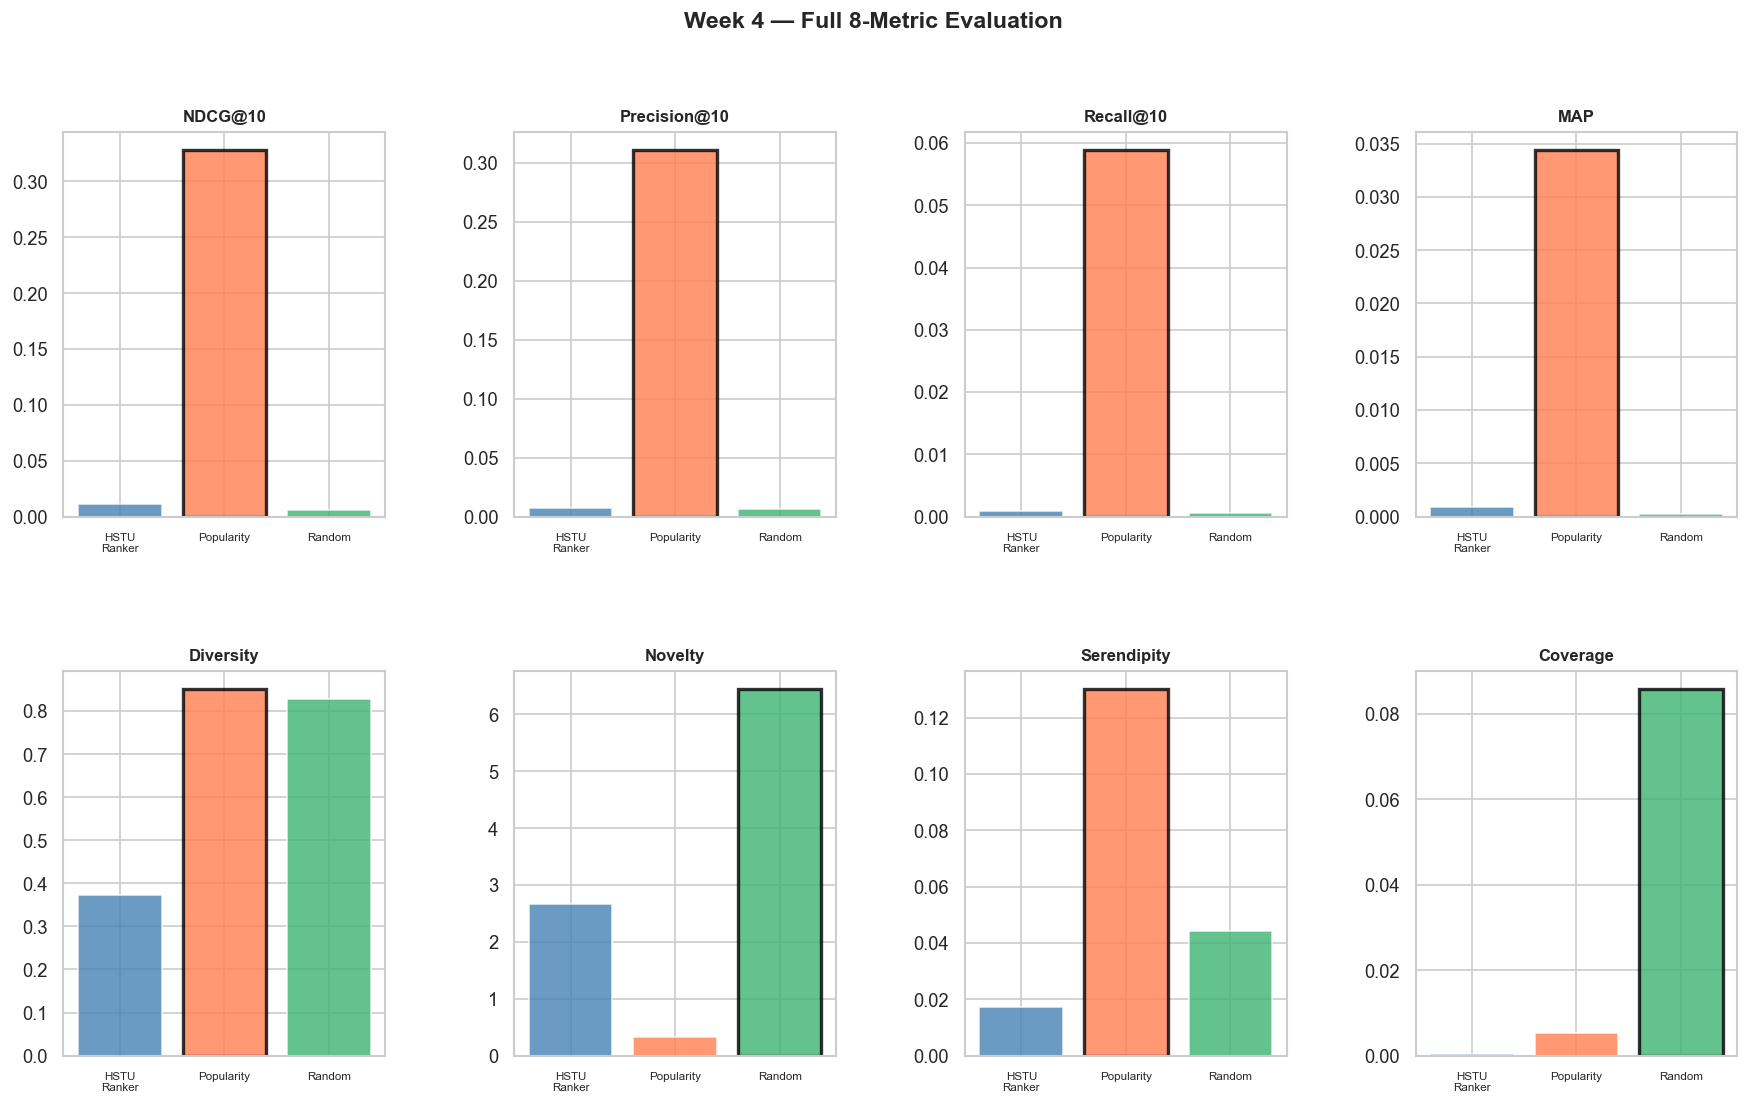

✅ Full evaluation plot saved


In [15]:
# Full Visualisation
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, fig,
                         hspace=0.4,
                         wspace=0.4)

metrics_plot = [
    ('ndcg@10',      'NDCG@10'),
    ('precision@10', 'Precision@10'),
    ('recall@10',    'Recall@10'),
    ('map',          'MAP'),
    ('diversity',    'Diversity'),
    ('novelty',      'Novelty'),
    ('serendipity',  'Serendipity'),
    ('coverage',     'Coverage'),
]

colors = ['steelblue', 'coral',
          'mediumseagreen']

for i, (metric, label) in \
        enumerate(metrics_plot):
    ax = fig.add_subplot(gs[i//4, i%4])

    if metric not in full_df.columns:
        continue

    vals   = pd.to_numeric(
        full_df[metric],
        errors='coerce').fillna(0)
    models = full_df['model'].tolist()

    bars = ax.bar(
        range(len(models)),
        vals,
        color=colors[:len(models)],
        alpha=0.8)

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [m.replace('_', '\n')
         for m in models],
        fontsize=7)
    ax.set_title(label,
                  fontweight='bold',
                  fontsize=10)

    # Highlight best
    if vals.max() > 0:
        best = vals.argmax()
        bars[best].set_edgecolor('black')
        bars[best].set_linewidth(2)

plt.suptitle(
    'Week 4 — Full 8-Metric Evaluation',
    fontsize=14, fontweight='bold')

plt.savefig(
    PROC + 'plots/22_full_evaluation.png',
    bbox_inches='tight', dpi=120)
plt.show()
print("✅ Full evaluation plot saved")

In [16]:
# MLflow + Save All
mlflow.set_tracking_uri(
    settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(
    settings.MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(
        run_name="Week4_Full_Evaluation"):

    for r in eval_results:
        model = r['model']\
            .replace(' ', '_')
        for metric in [
            'ndcg@10', 'precision@10',
            'recall@10', 'map',
            'diversity', 'novelty',
            'serendipity', 'coverage'
        ]:
            if metric in r and \
               isinstance(r[metric],
                          (int, float)):
                mlflow.log_metric(
                    f"{model}_"
                    f"{metric.replace('@','_at_')}",
                    float(r[metric]))

    mlflow.log_params({
        "week":          4,
        "n_metrics":     8,
        "n_eval_users":  len(eval_users),
        "cold_start":    "analysed",
        "bias_audit":    "analysed",
        "ips_correction":"applied",
    })

print("✅ MLflow logged")

# Summary JSON
day22_summary = {
    "eval_users":     len(eval_users),
    "metrics":        8,
    "models_eval":    len(eval_results),
    "cold_start":     cold_warm_results,
    "ips_comparison": ips_comparison,
    "data_quality": {
        "checks_passed": passed,
        "checks_total":  total,
    }
}

with open(PROC + 'day22_results.json',
          'w') as f:
    json.dump(day22_summary, f, indent=2)

print("✅ Day 22 results saved")
print(json.dumps(day22_summary, indent=2))

✅ MLflow logged
✅ Day 22 results saved
{
  "eval_users": 81,
  "metrics": 8,
  "models_eval": 3,
  "cold_start": [
    {
      "model": "HSTU_Ranker",
      "cold_ndcg": 0.0,
      "warm_ndcg": 0.0,
      "drop": 0.0
    },
    {
      "model": "Popularity",
      "cold_ndcg": 0.0,
      "warm_ndcg": 0.055,
      "drop": 0.055
    },
    {
      "model": "Random",
      "cold_ndcg": 0.0,
      "warm_ndcg": 0.0,
      "drop": 0.0
    }
  ],
  "ips_comparison": [
    {
      "model": "HSTU_Ranker",
      "raw_ndcg": 0.0117,
      "ips_ndcg": 0.0054,
      "diff": -0.0063
    },
    {
      "model": "Popularity",
      "raw_ndcg": 0.3305,
      "ips_ndcg": 0.1216,
      "diff": -0.2089
    },
    {
      "model": "Random",
      "raw_ndcg": 0.0088,
      "ips_ndcg": 0.0069,
      "diff": -0.0019
    }
  ],
  "data_quality": {
    "checks_passed": 9,
    "checks_total": 9
  }
}
